# 如何使用图形 API
本指南演示了 LangGraph Graph API 的基础知识。它涵盖了[状态](https://langchain-ai.github.io/langgraph/how-tos/graph-api/#define-and-update-state)，以及如何组合常见的图结构，例如[序列](https://langchain-ai.github.io/langgraph/how-tos/graph-api/#create-a-sequence-of-steps)、[分支](https://langchain-ai.github.io/langgraph/how-tos/graph-api/#create-branches)和[循环](https://langchain-ai.github.io/langgraph/how-tos/graph-api/#create-and-control-loops)。此外，它还涵盖了 LangGraph 的控制功能，包括用于map-reduce 工作流的Send API以及用于将状态更新与跨节点“跳跃”相结合的[Command API](https://langchain-ai.github.io/langgraph/how-tos/graph-api/#combine-control-flow-and-state-updates-with-command) 。

## 设置¶
安装langgraph：

`pip install -U langgraph`

> 注册LangSmith ，快速发现问题并提升 LangGraph 项目的性能。LangSmith 允许您使用跟踪数据来调试、测试和监控使用 LangGraph 构建的 LLM 应用——阅读文档，了解更多关于如何开始使用的信息。


## 定义和更新状态

这里我们展示如何在 LangGraph 中定义和更新[状态](https://langchain-ai.github.io/langgraph/concepts/low_level/#state)。我们将演示：

- 如何使用状态来定义图的[模式](https://langchain-ai.github.io/langgraph/concepts/low_level/#schema)
- 如何使用[Reducer](https://langchain-ai.github.io/langgraph/concepts/low_level/#reducers)来控制状态更新的处理方式。

### 定义状态¶
LangGraph 中的[状态](https://langchain-ai.github.io/langgraph/concepts/low_level/#state)可以是TypedDict、Pydantic模型或数据类。下面我们将使用TypedDict。有关使用 Pydantic 的详细信息，请参阅[本节](https://langchain-ai.github.io/langgraph/how-tos/graph-api/#use-pydantic-models-for-graph-state)。

默认情况下，图将具有相同的输入和输出架构，并且状态决定该架构。请参阅本节了解如何定义不同的输入和输出架构。

让我们考虑一个使用消息的[简单](https://langchain-ai.github.io/langgraph/concepts/low_level/#messagesstate)示例。这代表了许多 LLM 应用程序的通用状态表述。有关更多详细信息，请参阅我们的[概念页面](https://langchain-ai.github.io/langgraph/concepts/low_level/#working-with-messages-in-graph-state)。

API 参考：[AnyMessage](https://python.langchain.com/api_reference/core/messages/langchain_core.messages.AnyMessage.html?_gl=1*1j6qug1*_gcl_au*NDE1NjY4Mjc0LjE3NTM0Mjc3MTc.*_ga*MTEyMjY1OTA5MS4xNzUzNDI3NzE4*_ga_47WX3HKKY2*czE3NTM2MDQ3MjkkbzUkZzEkdDE3NTM2MDUxODgkajU5JGwwJGgw)



In [ ]:
from langchain_core.messages import AnyMessage
from typing_extensions import TypedDict

class State(TypedDict):
    messages: list[AnyMessage]
    extra_field: int

[此状态跟踪消息](https://python.langchain.com/docs/concepts/messages/?_gl=1*1i41hv8*_gcl_au*NDE1NjY4Mjc0LjE3NTM0Mjc3MTc.*_ga*MTEyMjY1OTA5MS4xNzUzNDI3NzE4*_ga_47WX3HKKY2*czE3NTM2MDQ3MjkkbzUkZzEkdDE3NTM2MDUxODgkajU5JGwwJGgw)对象列表以及额外的整数字段。

### 更新状态¶
让我们构建一个包含单个节点的示例图。我们的[节点](https://langchain-ai.github.io/langgraph/concepts/low_level/#nodes)只是一个 Python 函数，用于读取图的状态并对其进行更新。该函数的第一个参数始终是状态：

API 参考：[AIMessage](https://python.langchain.com/api_reference/core/messages/langchain_core.messages.ai.AIMessage.html?_gl=1*1kx6t8r*_gcl_au*NDE1NjY4Mjc0LjE3NTM0Mjc3MTc.*_ga*MTEyMjY1OTA5MS4xNzUzNDI3NzE4*_ga_47WX3HKKY2*czE3NTM2MDQ3MjkkbzUkZzEkdDE3NTM2MDUxODgkajU5JGwwJGgw)

In [ ]:
from langchain_core.messages import AIMessage

def node(state: State):
    messages = state["messages"]
    new_message = AIMessage("Hello!")
    return {"messages": messages + [new_message], "extra_field": 10}

该节点只是将一条消息附加到我们的消息列表中，并填充一个额外的字段。

> 节点应该直接返回状态更新，而不是改变状态。

接下来，我们定义一个包含此节点的简单图。我们使用[StateGraph](https://langchain-ai.github.io/langgraph/concepts/low_level/#stategraph)来定义一个在此状态上运行的图。然后，我们使用[add_node](https://langchain-ai.github.io/langgraph/concepts/low_level/#nodes)来填充我们的图。

API 参考：[StateGraph](https://langchain-ai.github.io/langgraph/reference/graphs/#langgraph.graph.state.StateGraph)


In [ ]:
from langgraph.graph import StateGraph

builder = StateGraph(State)
builder.add_node(node)
builder.set_entry_point("node")
graph = builder.compile()

LangGraph 提供了内置的可视化工具，方便您查看图表。让我们来检查一下我们的图表。有关可视化的详细信息，请参阅[本节](https://langchain-ai.github.io/langgraph/how-tos/graph-api/#visualize-your-graph)。

In [ ]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

<img src="https://langchain-ai.github.io/langgraph/how-tos/assets/graph_api_image_1.png">

在这种情况下，我们的图只执行单个节点。让我们继续一个简单的调用：

API 参考：[HumanMessage](https://python.langchain.com/api_reference/core/messages/langchain_core.messages.human.HumanMessage.html?_gl=1*1lkjxjj*_gcl_au*NDE1NjY4Mjc0LjE3NTM0Mjc3MTc.*_ga*MTEyMjY1OTA5MS4xNzUzNDI3NzE4*_ga_47WX3HKKY2*czE3NTM2MDQ3MjkkbzUkZzEkdDE3NTM2MDUxODgkajU5JGwwJGgw)

In [ ]:
from langchain_core.messages import HumanMessage

result = graph.invoke({"messages": [HumanMessage("Hi")]})
result

```json
{'messages': [HumanMessage(content='Hi'), AIMessage(content='Hello!')], 'extra_field': 10}
```

注意：

- 我们通过更新状态的单个键来启动调用。
- 我们在调用结果中收到整个状态。

为了方便起见，我们经常通过漂亮的打印来检查[消息对象](https://python.langchain.com/docs/concepts/messages/?_gl=1*1k7v6oq*_gcl_au*NDE1NjY4Mjc0LjE3NTM0Mjc3MTc.*_ga*MTEyMjY1OTA5MS4xNzUzNDI3NzE4*_ga_47WX3HKKY2*czE3NTM2MDQ3MjkkbzUkZzEkdDE3NTM2MDUxODgkajU5JGwwJGgw)的内容：

In [ ]:
for message in result["messages"]:
    message.pretty_print()

```shell
================================ Human Message ================================

Hi
================================== Ai Message ==================================

Hello!

```


### 使用 Reducer 进行状态更新¶

状态中的每个键都可以拥有自己独立的`Reducer`函数，该函数控制如何应用来自节点的更新。如果没有明确指定 `Reducer` 函数，则假定对该键的所有更新都应覆盖该函数。

对于TypedDict状态模式，我们可以通过使用 `Reducer` 函数注释状态的相应字段来定义 `Reducer`。

在前面的例子中，我们的节点`"messages"`通过向状态中的键附加一条消息来更新该键。下面，我们为该键添加一个 `Reducer`，以便自动附加更新：

In [ ]:
from typing_extensions import Annotated

def add(left, right):
    """Can also import `add` from the `operator` built-in."""
    return left + right

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add]
    extra_field: int

现在我们的节点可以简化了：

In [ ]:
def node(state: State):
    new_message = AIMessage("Hello!")
    return {"messages": [new_message], "extra_field": 10}

API 参考：[START](https://langchain-ai.github.io/langgraph/reference/constants/#langgraph.constants.START)

In [ ]:
from langgraph.graph import START

graph = StateGraph(State).add_node(node).add_edge(START, "node").compile()

result = graph.invoke({"messages": [HumanMessage("Hi")]})

for message in result["messages"]:
    message.pretty_print()

### 消息状态¶
在实践中，更新消息列表还需要考虑其他因素：

- 我们可能希望更新状态中现有的消息。
- 我们可能希望接受消息格式的简写，例如OpenAI 格式。
LangGraph reducer包含一个内置的  `add_messages`，可以处理以下问题：

API 参考：[add_messages](https://langchain-ai.github.io/langgraph/reference/graphs/#langgraph.graph.message.add_messages)

In [6]:
from langgraph.graph.message import add_messages
from typing_extensions import TypedDict, Annotated
from langchain_core.messages import AIMessage, AnyMessage
from langgraph.graph import StateGraph

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    extra_field: int

def node(state: State):
    new_message = AIMessage("Hello!")
    return {"messages": [new_message], "extra_field": 10}

graph = StateGraph(State).add_node(node).set_entry_point("node").compile()

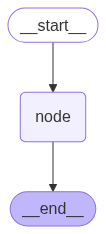

In [7]:
graph

In [8]:
input_message = {"role": "user", "content": "Hi"}

result = graph.invoke({"messages": [input_message]})

for message in result["messages"]:
    message.pretty_print()

================================ Human Message =================================

Hi
================================== Ai Message ==================================

Hello!


[这是涉及聊天模型](https://python.langchain.com/docs/concepts/chat_models/?_gl=1*3g8wb4*_gcl_au*NDE1NjY4Mjc0LjE3NTM0Mjc3MTc.*_ga*MTEyMjY1OTA5MS4xNzUzNDI3NzE4*_ga_47WX3HKKY2*czE3NTM2MDQ3MjkkbzUkZzEkdDE3NTM2MDUxODgkajU5JGwwJGgw)的应用程序的多功能状态表示。为了方便起见，LangGraph 包含预构建的功能MessagesState，以便我们可以拥有：

In [ ]:
from langgraph.graph import MessagesState

class State(MessagesState):
    extra_field: int

## 定义输入和输出模式¶
默认情况下，`StateGraph`使用单一架构运行，所有节点都应使用该架构进行通信。但是，也可以为图定义不同的输入和输出架构。

当指定不同的模式时，内部模式仍将用于节点之间的通信。输入模式确保提供的输入符合预期的结构，而输出模式则根据定义的输出模式过滤内部数据，仅返回相关信息。

下面，我们将看到如何定义不同的输入和输出模式。

API 参考：[StateGraph](https://langchain-ai.github.io/langgraph/reference/graphs/#langgraph.graph.state.StateGraph) |[开始](https://langchain-ai.github.io/langgraph/reference/constants/#langgraph.constants.START)|[结束](https://langchain-ai.github.io/langgraph/reference/constants/#langgraph.constants.END)

In [9]:
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict

# Define the schema for the input
class InputState(TypedDict):
    question: str

# Define the schema for the output
class OutputState(TypedDict):
    answer: str

# Define the overall schema, combining both input and output
class OverallState(InputState, OutputState):
    pass

# Define the node that processes the input and generates an answer
def answer_node(state: InputState):
    # Example answer and an extra key
    return {"answer": "bye", "question": state["question"]}

# Build the graph with input and output schemas specified
builder = StateGraph(OverallState, input_schema=InputState, output_schema=OutputState)
builder.add_node(answer_node)  # Add the answer node
builder.add_edge(START, "answer_node")  # Define the starting edge
builder.add_edge("answer_node", END)  # Define the ending edge
graph = builder.compile()  # Compile the graph

# Invoke the graph with an input and print the result
print(graph.invoke({"question": "hi"}))

{'answer': 'bye'}


请注意，invoke 的输出仅包含输出模式。

## 在节点之间传递私有状态¶
在某些情况下，您可能希望节点交换对中间逻辑至关重要的信息，但这些信息不必成为图主架构的一部分。这些私有数据与图的整体输入/输出无关，应该仅在某些节点之间共享。

下面，我们将创建一个由三个节点（`node_1`、`node_2` 和 `node_3`）组成的示例顺序图，其中私有数据在前两个步骤（`node_1` 和 `node_2`）之间传递，而第三步（`node_3`）只能访问公共整体状态。


API 参考：[StateGraph](https://langchain-ai.github.io/langgraph/reference/graphs/#langgraph.graph.state.StateGraph) |[开始](https://langchain-ai.github.io/langgraph/reference/constants/#langgraph.constants.START)|[结束](https://langchain-ai.github.io/langgraph/reference/constants/#langgraph.constants.END)

In [ ]:
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict

# The overall state of the graph (this is the public state shared across nodes)
class OverallState(TypedDict):
    a: str

# Output from node_1 contains private data that is not part of the overall state
class Node1Output(TypedDict):
    private_data: str

# Node 2 input only requests the private data available after node_1
class Node2Input(TypedDict):
    private_data: str

# The private data is only shared between node_1 and node_2
def node_1(state: OverallState) -> Node1Output:
    output = {"private_data": "set by node_1"}
    print(f"Entered node `node_1`:\n\tInput: {state}.\n\tReturned: {output}")
    return output



def node_2(state: Node2Input) -> OverallState:
    output = {"a": "set by node_2"}
    print(f"Entered node `node_2`:\n\tInput: {state}.\n\tReturned: {output}")
    return output

# Node 3 only has access to the overall state (no access to private data from node_1)
def node_3(state: OverallState) -> OverallState:
    output = {"a": "set by node_3"}
    print(f"Entered node `node_3`:\n\tInput: {state}.\n\tReturned: {output}")
    return output

# Connect nodes in a sequence
# node_2 accepts private data from node_1, whereas
# node_3 does not see the private data.
builder = StateGraph(OverallState).add_sequence([node_1, node_2, node_3])
builder.add_edge(START, "node_1")
graph = builder.compile()

# Invoke the graph with the initial state
response = graph.invoke(
    {
        "a": "set at start",
    }
)

print()
print(f"Output of graph invocation: {response}")

```shell
Entered node `node_1`:
    Input: {'a': 'set at start'}.
    Returned: {'private_data': 'set by node_1'}
Entered node `node_2`:
    Input: {'private_data': 'set by node_1'}.
    Returned: {'a': 'set by node_2'}
Entered node `node_3`:
    Input: {'a': 'set by node_2'}.
    Returned: {'a': 'set by node_3'}

Output of graph invocation: {'a': 'set by node_3'}
```

### 使用 Pydantic 模型来获取图形状态¶
`StateGraph`在初始化时接受一个参数，`state_schema`该参数指定图中节点可以访问和更新的状态的“形状”。

在我们的示例中，我们通常使用`python`-`nativeTypedDict`或`dataclassfor state_schema`，但`state_schema`可以是任何类型。

在这里，我们将看到如何使用`Pydantic BaseModel`对输入`state_schema`添加运行时验证。

> 目前，图表的输出不会是 pydantic 模型的实例。           
> 运行时验证仅发生在节点的输入上，而不是输出上。            
> pydantic 的验证错误跟踪并未显示错误发生在哪个节点。         
> Pydantic 的递归验证可能比较慢。对于性能敏感的应用程序，可以考虑使用dataclass。    


API 参考：[StateGraph](https://langchain-ai.github.io/langgraph/reference/graphs/#langgraph.graph.state.StateGraph) |[开始](https://langchain-ai.github.io/langgraph/reference/constants/#langgraph.constants.START)|[结束](https://langchain-ai.github.io/langgraph/reference/constants/#langgraph.constants.END)

In [ ]:
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict
from pydantic import BaseModel

# The overall state of the graph (this is the public state shared across nodes)
class OverallState(BaseModel):
    a: str

def node(state: OverallState):
    return {"a": "goodbye"}

# Build the state graph
builder = StateGraph(OverallState)
builder.add_node(node)  # node_1 is the first node
builder.add_edge(START, "node")  # Start the graph with node_1
builder.add_edge("node", END)  # End the graph after node_1
graph = builder.compile()

# Test the graph with a valid input
graph.invoke({"a": "hello"})

#### 使用无效输入调用图表


In [ ]:
try:
    graph.invoke({"a": 123})  # Should be a string
except Exception as e:
    print("An exception was raised because `a` is an integer rather than a string.")
    print(e)

```shell
An exception was raised because `a` is an integer rather than a string.
1 validation error for OverallState
a
  Input should be a valid string [type=string_type, input_value=123, input_type=int]
    For further information visit https://errors.pydantic.dev/2.9/v/string_type
```

当使用 Pydantic 模型作为状态模式时，了解序列化的工作原理非常重要，尤其是在以下情况下：- 将 Pydantic 对象作为输入传递 - 从图中接收输出 - 使用嵌套的 Pydantic 模型

让我们看看这些行为的实际效果。

In [ ]:
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel

class NestedModel(BaseModel):
    value: str

class ComplexState(BaseModel):
    text: str
    count: int
    nested: NestedModel

def process_node(state: ComplexState):
    # Node receives a validated Pydantic object
    print(f"Input state type: {type(state)}")
    print(f"Nested type: {type(state.nested)}")
    # Return a dictionary update
    return {"text": state.text + " processed", "count": state.count + 1}

# Build the graph
builder = StateGraph(ComplexState)
builder.add_node("process", process_node)
builder.add_edge(START, "process")
builder.add_edge("process", END)
graph = builder.compile()

# Create a Pydantic instance for input
input_state = ComplexState(text="hello", count=0, nested=NestedModel(value="test"))
print(f"Input object type: {type(input_state)}")

# Invoke graph with a Pydantic instance
result = graph.invoke(input_state)
print(f"Output type: {type(result)}")
print(f"Output content: {result}")

# Convert back to Pydantic model if needed
output_model = ComplexState(**result)
print(f"Converted back to Pydantic: {type(output_model)}")

Pydantic 会对某些数据类型进行运行时类型强制转换。这可能会很有帮助，但如果您没有意识到这一点，也会导致意外行为。

In [ ]:
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel

class CoercionExample(BaseModel):
    # Pydantic will coerce string numbers to integers
    number: int
    # Pydantic will parse string booleans to bool
    flag: bool

def inspect_node(state: CoercionExample):
    print(f"number: {state.number} (type: {type(state.number)})")
    print(f"flag: {state.flag} (type: {type(state.flag)})")
    return {}

builder = StateGraph(CoercionExample)
builder.add_node("inspect", inspect_node)
builder.add_edge(START, "inspect")
builder.add_edge("inspect", END)
graph = builder.compile()

# Demonstrate coercion with string inputs that will be converted
result = graph.invoke({"number": "42", "flag": "true"})

# This would fail with a validation error
try:
    graph.invoke({"number": "not-a-number", "flag": "true"})
except Exception as e:
    print(f"\nExpected validation error: {e}")

在状态模式中使用 LangChain 消息类型时，序列化有一些重要的注意事项。在通过线路使用消息对象时，应使用 `AnyMessage`（而不是 `BaseMessage`）进行正确的序列化/解序列化。

In [ ]:
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel
from langchain_core.messages import HumanMessage, AIMessage, AnyMessage
from typing import List

class ChatState(BaseModel):
    messages: List[AnyMessage]
    context: str

def add_message(state: ChatState):
    return {"messages": state.messages + [AIMessage(content="Hello there!")]}

builder = StateGraph(ChatState)
builder.add_node("add_message", add_message)
builder.add_edge(START, "add_message")
builder.add_edge("add_message", END)
graph = builder.compile()

# Create input with a message
initial_state = ChatState(
    messages=[HumanMessage(content="Hi")], context="Customer support chat"
)

result = graph.invoke(initial_state)
print(f"Output: {result}")

# Convert back to Pydantic model to see message types
output_model = ChatState(**result)
for i, msg in enumerate(output_model.messages):
    print(f"Message {i}: {type(msg).__name__} - {msg.content}")

## 添加运行时配置¶
有时，您希望能够在调用图时对其进行配置。例如，您可能希望能够指定在运行时使用哪个 LLM 或系统提示符，但又不让这些参数污染图的状态。

要添加运行时配置：

- 为您的配置指定架构
- 将配置添加到节点或条件边的函数签名中
- 将配置传递到图表中。

请参阅下面的简单示例：

API 参考：[结束](https://langchain-ai.github.io/langgraph/reference/constants/#langgraph.constants.END)|[状态图](https://langchain-ai.github.io/langgraph/reference/graphs/#langgraph.graph.state.StateGraph)|[开始](https://langchain-ai.github.io/langgraph/reference/constants/#langgraph.constants.START)

In [10]:
from langgraph.graph import END, StateGraph, START
from langgraph.runtime import Runtime
from typing_extensions import TypedDict

# 1. Specify config schema
class ContextSchema(TypedDict):
    my_runtime_value: str

# 2. Define a graph that accesses the config in a node
class State(TypedDict):
    my_state_value: str

def node(state: State, runtime: Runtime[ContextSchema]):
    if runtime.context["my_runtime_value"] == "a":
        return {"my_state_value": 1}
    elif runtime.context["my_runtime_value"] == "b":
        return {"my_state_value": 2}
    else:
        raise ValueError("Unknown values.")

builder = StateGraph(State, context_schema=ContextSchema)
builder.add_node(node)
builder.add_edge(START, "node")
builder.add_edge("node", END)

graph = builder.compile()

# 3. Pass in configuration at runtime:
print(graph.invoke({}, context={"my_runtime_value": "a"}))
print(graph.invoke({}, context={"my_runtime_value": "b"}))

ModuleNotFoundError: No module named 'langgraph.runtime'

## 添加重试策略
在许多用例中，您可能希望节点具有自定义重试策略，例如，如果您正在调用 API、查询数据库或调用 LLM 等。LangGraph 允许您向节点添加重试策略。

要配置重试策略，请将`retry_policy`参数传递给[`add_node`](https://langchain-ai.github.io/langgraph/reference/graphs/#langgraph.graph.state.StateGraph.add_node)。该`retry_policy`参数接受一个`RetryPolicy`命名的元组对象。下面我们`RetryPolicy`使用默认参数实例化一个对象，并将其与一个节点关联：

In [ ]:
from langgraph.pregel import RetryPolicy

builder.add_node(
    "node_name",
    node_function,
    retry_policy=RetryPolicy(),
)

默认情况下，该retry_on参数使用该default_retry_on函数，该函数会在出现以下情况之外的任何异常时重试：

- ValueError
- TypeError
- ArithmeticError
- ImportError
- LookupError
- NameError
- SyntaxError
- RuntimeError
- ReferenceError
- StopIteration
- StopAsyncIteration
- OSError

此外，对于流行的 http 请求库（例如requests）的异常httpx，它只会在 5xx 状态代码上重试。

## 添加节点缓存¶
当您想要避免重复操作时，例如执行一些耗时（无论是时间还是成本）的操作时，节点缓存非常有用。LangGraph 允许您为图中的节点添加个性化的缓存策略。

要配置缓存策略，请将cache_policy参数传递给add_node函数。在以下示例中，CachePolicy实例化一个对象，其生存时间为 120 秒，并使用默认key_func生成器。然后，该对象与一个节点关联：

In [ ]:
from langgraph.types import CachePolicy

builder.add_node(
    "node_name",
    node_function,
    cache_policy=CachePolicy(ttl=120),
)

然后，要为图启用节点级缓存，请`cache`在编译图时设置参数。以下示例用于`InMemoryCache`设置带有内存缓存的图，但`SqliteCache`也可用。

In [ ]:
from langgraph.cache.memory import InMemoryCache

graph = builder.compile(cache=InMemoryCache())

## 创建一系列步骤
这里我们演示如何构建一个简单的步骤序列。我们将展示：

- 如何构建顺序图
- 内置用于构建类似图表的简写。

要添加节点序列，我们使用[图](https://langchain-ai.github.io/langgraph/concepts/low_level/#stategraph)的`.add_node`和`.add_edge`方法：

API 参考：[START](https://langchain-ai.github.io/langgraph/reference/constants/#langgraph.constants.START) | [StateGraph](https://langchain-ai.github.io/langgraph/reference/graphs/#langgraph.graph.state.StateGraph)

In [ ]:
from langgraph.graph import START, StateGraph

builder = StateGraph(State)

# Add nodes
builder.add_node(step_1)
builder.add_node(step_2)
builder.add_node(step_3)

# Add edges
builder.add_edge(START, "step_1")
builder.add_edge("step_1", "step_2")
builder.add_edge("step_2", "step_3")

我们还可以使用内置的简写`.add_sequence`：

In [ ]:
builder = StateGraph(State).add_sequence([step_1, step_2, step_3])
builder.add_edge(START, "step_1")

让我们演示一个端到端的示例。我们将创建一个包含三个步骤的序列：

- 在状态的键中填充值
- 更新相同的值
- 填充不同的值

首先，我们来定义一下[状态](https://langchain-ai.github.io/langgraph/concepts/low_level/#state)。状态决定了[图的模式](https://langchain-ai.github.io/langgraph/concepts/low_level/#schema)，并指定如何应用更新。更多详细信息，请参阅[本节](https://langchain-ai.github.io/langgraph/how-tos/graph-api/#process-state-updates-with-reducers)。

在我们的例子中，我们只需跟踪两个值：

In [ ]:
from typing_extensions import TypedDict

class State(TypedDict):
    value_1: str
    value_2: int

我们的[节点](https://langchain-ai.github.io/langgraph/concepts/low_level/#nodes)只是一些 Python 函数，用于读取图的状态并进行更新。该函数的第一个参数始终是状态：

In [ ]:
def step_1(state: State):
    return {"value_1": "a"}

def step_2(state: State):
    current_value_1 = state["value_1"]
    return {"value_1": f"{current_value_1} b"}

def step_3(state: State):
    return {"value_2": 10}

最后，我们定义图。我们使用[StateGraph](https://langchain-ai.github.io/langgraph/concepts/low_level/#stategraph)来定义一个在此状态上进行操作的图。

然后我们将使用[add_node](https://langchain-ai.github.io/langgraph/concepts/low_level/#messagesstate)和[add_edge](https://langchain-ai.github.io/langgraph/concepts/low_level/#edges)来填充我们的图并定义其控制流。

API 参考：[START](https://langchain-ai.github.io/langgraph/reference/constants/#langgraph.constants.START) | [StateGraph](https://langchain-ai.github.io/langgraph/reference/graphs/#langgraph.graph.state.StateGraph)



In [ ]:
from langgraph.graph import START, StateGraph

builder = StateGraph(State)

# Add nodes
builder.add_node(step_1)
builder.add_node(step_2)
builder.add_node(step_3)

# Add edges
builder.add_edge(START, "step_1")
builder.add_edge("step_1", "step_2")
builder.add_edge("step_2", "step_3")

> 您可以使用以下方式为节点指定自定义名称`.add_node`：


`builder.add_node("my_node", step_1)`

注意：

- `.add_edge`采用节点的名称，对于函数，默认为`node.__name__`。
- 我们必须指定图的入口点。为此，我们添加一条以[START 节点](https://langchain-ai.github.io/langgraph/concepts/low_level/#start-node)为边。
- 当没有更多节点需要执行时，图表就会停止。

接下来，我们编译我们的图。这会对图的结构进行一些基本检查（例如，识别孤立节点）。如果我们通过检查点 (checkpointer ) 为应用程序添加持久性，它也会被传递到这里。




### END节点¶
NodeEND是一个特殊节点，表示终端节点。当需要指示哪些边在完成后没有操作时，可以引用此节点。



In [ ]:
from langgraph.graph import END

graph.add_edge("node_a", END)

### 节点缓存¶
LangGraph 支持根据节点的输入缓存任务/节点。使用缓存的方法如下：

- 编译图表时指定缓存（或指定入口点）
- 指定节点的缓存策略。每个缓存策略支持：
    - key_func用于根据节点的输入生成缓存键，默认为hash使用 pickle 的输入。
    - ttl，缓存的生存时间（以秒为单位）。如果未指定，则缓存永不过期。
例如：

API 参考：StateGraph

In [ ]:
import time
from typing_extensions import TypedDict
from langgraph.graph import StateGraph
from langgraph.cache.memory import InMemoryCache
from langgraph.types import CachePolicy


class State(TypedDict):
    x: int
    result: int


builder = StateGraph(State)


def expensive_node(state: State) -> dict[str, int]:
    # expensive computation
    time.sleep(2)
    return {"result": state["x"] * 2}


builder.add_node("expensive_node", expensive_node, cache_policy=CachePolicy(ttl=3))
builder.set_entry_point("expensive_node")
builder.set_finish_point("expensive_node")

graph = builder.compile(cache=InMemoryCache())

print(graph.invoke({"x": 5}, stream_mode='updates'))  
[{'expensive_node': {'result': 10}}]
print(graph.invoke({"x": 5}, stream_mode='updates'))  
[{'expensive_node': {'result': 10}, '__metadata__': {'cached': True}}]

## 边缘¶
边定义了逻辑的路由方式以及图的终止方式。这在很大程度上决定了代理的工作方式以及不同节点之间的通信方式。边有几种主要类型：

- 普通边：直接从一个节点到下一个节点。
- 条件边：调用一个函数来确定下一步要去哪个节点。
- 入口点：当用户输入到达时首先调用哪个节点。
- 条件入口点：调用一个函数来确定当用户输入到达时首先调用哪个节点。

一个节点可以有多个出边。如果一个节点有多个出边，则所有这些目标节点将作为下一个超级步骤的一部分并行执行。

### 法线边¶
如果总是想从节点A到节点B，那么可以直接使用[add_edge](https://langchain-ai.github.io/langgraph/reference/graphs/#langgraph.graph.state.StateGraph.add_edge)方法。


In [ ]:
graph.add_edge("node_a", "node_b")

### 条件边¶
如果您希望选择性地路由到一条或多条边（或选择性地终止），可以使用[add_conditional_edges](https://langchain-ai.github.io/langgraph/reference/graphs/#langgraph.graph.state.StateGraph.add_conditional_edges)方法。此方法接受节点名称以及执行该节点后要调用的“路由函数”。

In [ ]:
graph.add_conditional_edges("node_a", routing_function)

与节点类似，接受图的`routing_function`并当前state返回一个值。

默认情况下，返回值`routing_function`将用作将状态发送到下一个节点（或节点列表）的名称。所有这些节点将作为下一个超级步骤的一部分并行运行。

您可以选择提供一个字典，将`routing_function` 的输出映射到下一个节点的名称。

In [ ]:
graph.add_conditional_edges("node_a", 
                            routing_function, 
                            {True: "node_b", False: "node_c"})

### 入口点¶
入口点是图启动时运行的第一个节点。您可以使用[add_edge](https://langchain-ai.github.io/langgraph/reference/graphs/#langgraph.graph.state.StateGraph.add_edge)从虚拟[START](https://langchain-ai.github.io/langgraph/reference/constants/#langgraph.constants.START)节点到第一个要执行的节点的方法来指定图的入口点。

API 参考：[START](https://langchain-ai.github.io/langgraph/reference/constants/#langgraph.constants.START)

In [ ]:
from langgraph.graph import START

graph.add_edge(START, "node_a")

### 条件入口点¶
条件入口点允许您根据自定义逻辑从不同的节点启动。您可以使用[add_conditional_edges](https://langchain-ai.github.io/langgraph/reference/graphs/#langgraph.graph.state.StateGraph.add_conditional_edges)虚拟[START](https://langchain-ai.github.io/langgraph/reference/constants/#langgraph.constants.START)节点来实现这一点。

API 参考：START

In [ ]:
from langgraph.graph import START

graph.add_conditional_edges(START, routing_function)

您可以选择提供一个字典，将`routing_function` 的输出映射到下一个节点的名称。

## Send¶
默认情况下，`Nodes`和`Edges`是提前定义的，并在相同的共享状态下运行。但是，在某些情况下，确切的边无法提前知道，并且/或者您可能希望`State`同时存在 的不同版本。一个常见的例子是[map-reduce](https://langchain-ai.github.io/langgraph/how-tos/map-reduce/)设计模式。在这种设计模式中，第一个节点可能会生成一个对象列表，您可能希望将其他节点应用于所有这些对象。对象的数量可能提前未知（这意味着边的数量可能未知），并且`State`下游的输入`Node`应该不同（每个生成的对象对应一个输入）。

为了支持这种设计模式，LangGraph 支持[Send](https://langchain-ai.github.io/langgraph/reference/types/#langgraph.types.Send)从条件边返回对象。`Send`接受两个参数：第一个是节点的名称，第二个是传递给该节点的状态。

In [ ]:
def continue_to_jokes(state: OverallState):
    return [Send("generate_joke", {"subject": s}) for s in state['subjects']]

graph.add_conditional_edges("node_a", continue_to_jokes)

## Command¶
将控制流（边）和状态更新（节点）结合起来会很有用。例如，你可能希望在同一个节点中同时执行状态更新和决定下一步要转到哪个节点。LangGraph 提供了一种方法，它通过[Command](https://langchain-ai.github.io/langgraph/reference/types/#langgraph.types.Command)从节点函数返回一个对象来实现：




In [ ]:
def my_node(state: State) -> Command[Literal["my_other_node"]]:
    return Command(
        # state update
        update={"foo": "bar"},
        # control flow
        goto="my_other_node"
    )

您Command还可以实现动态控制流行为（与[条件边](https://langchain-ai.github.io/langgraph/concepts/low_level/#conditional-edges)相同）：

In [ ]:
def my_node(state: State) -> Command[Literal["my_other_node"]]:
    if state["foo"] == "bar":
        return Command(update={"foo": "baz"}, goto="my_other_node")

> 在节点函数中返回时`Command`，必须添加返回类型注释，其中包含节点路由到的节点名称列表，例如`Command[Literal["my_other_node"]]`。这对于图形渲染是必需的，它告诉 `LangGraph` `my_node`可以导航到`my_other_node`。

### 什么时候应该使用命令而不是条件边？¶
Command当您需要同时更新图形状态和路由到其他节点时使用。例如，在实现多代理切换时，需要路由到其他代理并向该代理传递一些信息。

使用条件边在节点之间有条件地路由而不更新状态。

### 导航到父图中的节点

如果使用[子图](https://langchain-ai.github.io/langgraph/concepts/subgraphs/)，您可能希望从子图中的节点导航到不同的子图（即父图中的不同节点）。为此，您可以在命令中指定 `graph=Command.PARENT`：



In [ ]:
def my_node(state: State) -> Command[Literal["other_subgraph"]]:
    return Command(
        update={"foo": "bar"},
        goto="other_subgraph",  # where `other_subgraph` is a node in the parent graph
        graph=Command.PARENT
    )

> 设置graph为Command.PARENT将导航到最近的父图。

> 当您将某个键的更新从子图节点发送到父图节点时，如果该键由父图状态模式和子图状态模式共享，则必须为父图状态中要更新的键定义一个Reducer 。请参阅此示例。

### 使用内部工具¶
一个常见的用例是从工具内部更新图谱状态。例如，在客户支持应用中，你可能希望在对话开始时根据客户的账号或 ID 查找客户信息。

请参阅本指南以了解详细信息。


### 人机交互¶
Command是人机交互工作流程的重要组成部分：当使用`interrupt()`收集用户输入时，`Command`会使用 提供输入并通过 恢复执行`Command(resume="User input")`。查看此概念指南了解更多信息。

## 图形迁移¶
即使使用检查点来跟踪状态，LangGraph 也可以轻松处理图形定义（节点、边和状态）的迁移。

- 对于图末尾的线程（即未中断），您可以更改图的整个拓扑（即所有节点和边，删除、添加、重命名等）
- 对于当前中断的线程，我们支持除重命名/删除节点之外的所有拓扑更改（因为该线程现在可能即将进入不再存在的节点） - 如果这是一个阻止程序，请联系我们，我们可以优先解决。
- 对于修改状态，我们对添加和删除键具有完全的向后和向前兼容性
- 重命名的状态键会丢失其在现有线程中保存的状态
- 状态键的类型以不兼容的方式发生变化目前可能会导致具有更改之前状态的线程出现问题 - 如果这是一个阻碍，请联系我们，我们可以优先解决。

## 运行时上下文¶
创建图时，您可以指定传递context_schema给节点的运行时上下文。这对于将不属于图状态的信息传递给节点非常有用。例如，您可能希望传递模型名称或数据库连接等依赖项。

In [ ]:
@dataclass
class ContextSchema:
    llm_provider: str = "openai"

graph = StateGraph(State, context_schema=ContextSchema)

然后，您可以使用 invoke 方法的上下文参数将此上下文传递到图形中。

In [ ]:
graph.invoke(inputs, context={"llm_provider": "anthropic"})

然后您可以在节点或条件边内访问和使用此上下文：

In [ ]:
from langgraph.runtime import Runtime

def node_a(state: State, runtime: Runtime[ContextSchema]):
    llm = get_llm(runtime.context.llm_provider)
    ...

## 递归限制¶
递归限制设置了图在单次执行期间可以执行的超级步骤的最大数量。一旦达到限制，LangGraph 将提升`GraphRecursionError`。默认情况下，此值设置为 25 步。可以在运行时在任何图上设置递归限制，并将其传递给`.invoke/.stream`通过配置字典。重要的是，`recursion_limit`是一个独立的`config`键，不应`configurable`像所有其他用户定义的配置一样在键内传递。请参见以下示例：

In [ ]:
graph.invoke(inputs, config={"recursion_limit": 5}, context={"llm": "anthropic"})

## 可视化¶
能够将图形可视化通常是一件很棒的事情，尤其是在图形变得越来越复杂的时候。LangGraph 内置了几种可视化图形的方法。更多信息，请参阅此操作指南。